# Step 6 JAM aperture velocity dispersion

This notebook reads three Step 6 posteriors, randomly selects posterior samples from each run, converts the stellar-light MGE plus gNFW halo MGE into the input convention used by `jampy`, computes the luminosity-weighted central aperture velocity dispersion within 1 arcsec, and makes an overlaid corner plot.

Convention check: `jampy` expects `surf_lum` to be the peak MGE surface brightness and `surf_pot` to be the peak total-mass surface density in `Msun / pc^2`. The Herculens/lenstronomy Gaussian `amp` is an integrated 2D amplitude, so the corresponding peak value is `amp / (2 pi sigma_product^2)`. In contrast, the Jax-Lensing-Profiles `MGE.decompose()` amplitudes are already in the peak projected-convergence convention used by its MGE lensing formulae, so they should not be divided by `2 pi sigma^2` or multiplied by an extra projection factor before passing to JAM. Because Herculens uses the product-average ellipticity convention, the JAM major-axis dispersion is `sigma_jam = sigma_product / sqrt(qobs)`.

The M/L-gradient stellar mass amplitudes are recomputed exactly as in the Step 6 script: `mass_from_light_amp = light_amp / sum(light_amp) * m2l_ratio * sigma**m2l_ratio_slope`.

Note: the calculation below uses the axisymmetric JAM approximation. It recenters the dynamical model on the flux-weighted stellar MGE centroid and treats all MGE components as coaxial. The posterior halo center offset and external perturbers/shear/convergence are lensing ingredients and are not included as local stellar-dynamical mass components here.


## References for conventions

JAMPY `jam.axi.proj` expects `surf_lum` to be the peak MGE surface brightness and `surf_pot` to be the peak total-mass surface density. Herculens/lenstronomy Gaussian `amp` is the integrated two-dimensional amplitude. The Step 6 M/L gradient formula is copied from `Step_6_stardm_model_imaging_only_to_hmc.py`. For the gNFW halo, the Jax-Lensing-Profiles MGE decomposition is already consumed as peak projected convergence by its own MGE lensing routines, so those amplitudes are passed to JAM as peak values.


In [1]:
# ============================================================
# Imports
# ============================================================
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

from pathlib import Path

import arviz as az
import corner
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import numpy as np
import pandas as pd
import xarray as xr
from astropy import constants as const
from astropy import units as u
from astropy.cosmology import FlatLambdaCDM
from tqdm.auto import tqdm

import jampy as jam

from jax_lensing_profiles.MassModel.Profiles.CuspyNFW_ellipse_kappa import CuspyNFW_3D_fn
from jax_lensing_profiles.MassModel.Profiles.MGE import MGE

jax.config.update("jax_enable_x64", True)


In [2]:
# ============================================================
# Configuration
# ============================================================
RUN_CONFIGS = {
    'infer_h0_imaging_only': {
        'label': 'Infer H0 imaging-only',
        'color': '#2f7f4f',
        'nc_path': '/mnt/lustre/tianli/quasar_hmc/WFI2033_inferh0_step6_imaging_only_infer_LCDM_20260502_08/WFI2033_all_inferh0_step6_imaging_only_infer_LCDM.nc',
    },
    'desi_planck': {
        'label': 'DESI+Planck Cosmology',
        'color': '#356ab7',
        'nc_path': '/mnt/lustre/tianli/quasar_hmc/WFI2033_ss=2_fullconcen_light_multimass_step6_desi_planck_reuse_redwarmup_20260509_06/WFI2033_all_ss=2_fullconcen_light_multimass_step6_desi_planck_reuse_redwarmup.nc',
    },
    'pantheon_sh0es': {
        'label': 'Pantheon+SH0ES Cosmology',
        'color': '#c44e52',
        'nc_path': '/mnt/lustre/tianli/quasar_hmc/WFI2033_ss=2_fullconcen_light_multimass_step6_pantheonsh0es_reuse_redwarmup_20260507_14/WFI2033_all_ss=2_fullconcen_light_multimass_step6_pantheonsh0es_reuse_redwarmup.nc',
    },
}

FIXED_FIVE_GAUSS_PATH = './result/result_ss=2_fullconcen_light_multimass_20260427_14/fixed_five_gaussians_corrected_psf_ss=2_fullconcen_light_multimass.npz'

Z_LENS = 0.6575
Z_SOURCE = 1.662
N_RANDOM_SAMPLES = 1000
RNG_SEED = 2033
APER_RADIUS_ARCSEC = 1.0
APER_GRID_SIDE = 41
INC_DEG = 90.0
BETA_POPULATION_MEAN = 0.12
BETA_POPULATION_SCATTER = 0.03
BETA_MIN = 0.0
BETA_MAX = 0.95
MBH_MSUN = 0.0

CORNER_OUT = './Paper/jampy_sigma_ap_corner_overlay.pdf'

POST_VARS = [
    'm2l_ratio', 'm2l_ratio_slope',
    'kappa_s_halo', 'gammain_halo', 'Rs_halo', 'e_halo', 'center_halo',
    'omega_m_cosmo', 'H0_cosmo',
]

for run_name, cfg in RUN_CONFIGS.items():
    print(f'{run_name}: {cfg["nc_path"]}')
print('FIXED_FIVE_GAUSS_PATH =', FIXED_FIVE_GAUSS_PATH)


infer_h0_imaging_only: /mnt/lustre/tianli/quasar_hmc/WFI2033_inferh0_step6_imaging_only_infer_LCDM_20260502_08/WFI2033_all_inferh0_step6_imaging_only_infer_LCDM.nc
desi_planck: /mnt/lustre/tianli/quasar_hmc/WFI2033_ss=2_fullconcen_light_multimass_step6_desi_planck_reuse_redwarmup_20260509_06/WFI2033_all_ss=2_fullconcen_light_multimass_step6_desi_planck_reuse_redwarmup.nc
pantheon_sh0es: /mnt/lustre/tianli/quasar_hmc/WFI2033_ss=2_fullconcen_light_multimass_step6_pantheonsh0es_reuse_redwarmup_20260507_14/WFI2033_all_ss=2_fullconcen_light_multimass_step6_pantheonsh0es_reuse_redwarmup.nc
FIXED_FIVE_GAUSS_PATH = ./result/result_ss=2_fullconcen_light_multimass_20260427_14/fixed_five_gaussians_corrected_psf_ss=2_fullconcen_light_multimass.npz


In [3]:
# ============================================================
# Load the fixed five-Gaussian stellar light MGE
# ============================================================
fixed = np.load(FIXED_FIVE_GAUSS_PATH)
light_amp = fixed['amp'].astype(float)
sigma_prod = fixed['sigma'].astype(float)
e1_light = fixed['e1'].astype(float)
e2_light = fixed['e2'].astype(float)
center_x = fixed['center_x'].astype(float)
center_y = fixed['center_y'].astype(float)

print('fixed MGE keys:', fixed.files)
for key in fixed.files:
    print(f'{key:8s}', fixed[key])

light_centroid = np.array([np.sum(light_amp * center_x) / np.sum(light_amp), np.sum(light_amp * center_y) / np.sum(light_amp)])
print('flux-weighted stellar MGE centroid [arcsec] =', light_centroid)


fixed MGE keys: ['amp', 'sigma', 'e1', 'e2', 'center_x', 'center_y']
amp      [ 126.87107673  107.75939469  214.76170615  618.59013138 2013.69845619]
sigma    [0.01904452 0.04217237 0.09683986 0.24231872 0.85271635]
e1       [-0.14037145 -0.0578769  -0.08466947 -0.04794419 -0.05653835]
e2       [-0.01248935  0.06503772  0.11774388  0.11001114  0.1275457 ]
center_x [-0.002724    0.00140216  0.00030878  0.00230782  0.00230782]
center_y [-0.01424388 -0.00944529 -0.01407877 -0.01382772 -0.01382772]
flux-weighted stellar MGE centroid [arcsec] = [ 0.00192968 -0.0137091 ]


In [4]:
# ============================================================
# Geometry and unit helpers
# ============================================================
def ellipticity_to_q_phi(e1, e2):
    ellip = np.minimum(np.sqrt(np.asarray(e1, dtype=float)**2 + np.asarray(e2, dtype=float)**2), 0.9999)
    q = (1.0 - ellip) / (1.0 + ellip)
    phi = 0.5 * np.arctan2(e2, e1)
    return q, phi


def sigma_crit_and_scale(H0, Om0, z_lens=Z_LENS, z_source=Z_SOURCE):
    cosmo = FlatLambdaCDM(H0=float(H0) * u.km / u.s / u.Mpc, Om0=float(Om0))
    D_d = cosmo.angular_diameter_distance(z_lens)
    D_s = cosmo.angular_diameter_distance(z_source)
    D_ds = cosmo.angular_diameter_distance_z1z2(z_lens, z_source)
    sigma_crit = (const.c**2 / (4.0 * np.pi * const.G) * D_s / (D_d * D_ds)).to(u.Msun / u.pc**2)
    pc_per_arcsec = (D_d.to(u.pc) * (1.0 * u.arcsec).to(u.rad).value).value
    return sigma_crit.value, pc_per_arcsec, D_d.to(u.Mpc).value


def herculens_integrated_amp_to_jam_peak(amp_integrated, sigma_product):
    return np.asarray(amp_integrated, dtype=float) / (2.0 * np.pi * np.asarray(sigma_product, dtype=float)**2)


def herculens_sigma_product_to_jam_major_sigma(sigma_product, qobs):
    return np.asarray(sigma_product, dtype=float) / np.sqrt(np.asarray(qobs, dtype=float))


def projected_mge_surface(x, y, surf_peak, sigma_major, qobs):
    x = np.asarray(x)[:, None]
    y = np.asarray(y)[:, None]
    surf_peak = np.asarray(surf_peak, dtype=float)[None, :]
    sigma_major = np.asarray(sigma_major, dtype=float)[None, :]
    qobs = np.asarray(qobs, dtype=float)[None, :]
    expo = -0.5 * ((x / sigma_major)**2 + (y / (sigma_major * qobs))**2)
    return np.sum(surf_peak * np.exp(expo), axis=1)


def aperture_grid(radius_arcsec=APER_RADIUS_ARCSEC, side=APER_GRID_SIDE):
    grid = np.linspace(-radius_arcsec, radius_arcsec, side)
    xx, yy = np.meshgrid(grid, grid, indexing='xy')
    mask = xx**2 + yy**2 <= radius_arcsec**2
    mask &= (xx != 0.0) | (yy != 0.0)
    return xx[mask].ravel(), yy[mask].ravel()

x_ap, y_ap = aperture_grid()
print('aperture grid points:', x_ap.size)


aperture grid points: 1252


In [5]:
# ============================================================
# gNFW MGE decomposition with the same numerical setup as Step 6
# ============================================================
class CuspyNFWEllipseKappaForJAM(MGE):
    def __init__(self):
        super().__init__(CuspyNFW_3D_fn, 'R_s', n_gauss=20, n_terms=28, sigma_start_mult=1/200, sigma_end_mult=20, three_d=True)

halo_mge = CuspyNFWEllipseKappaForJAM()

def halo_mge_projected_peak_kappa_and_sigma(Rs_halo, kappa_s_halo, gammain_halo):
    amps_projected_peak_kappa, sigmas_product = halo_mge.decompose(R_s=float(Rs_halo), kappa_s=float(kappa_s_halo), gamma=float(gammain_halo))
    return np.asarray(amps_projected_peak_kappa, dtype=float), np.asarray(sigmas_product, dtype=float)


In [6]:
# ============================================================
# Read only the scalar/vector parameters needed for JAM
# ============================================================
def load_sampled_posterior(run_name, cfg):
    print(f'opening {run_name}: {cfg["nc_path"]}')
    post_i = xr.open_dataset(cfg['nc_path'], group='posterior', engine='h5netcdf')[POST_VARS].load()
    stacked_i = post_i.stack(sample=('chain', 'draw'))
    n_total_i = int(stacked_i.sizes['sample'])
    rng_i = np.random.default_rng(RNG_SEED + list(RUN_CONFIGS).index(run_name))
    sample_indices_i = rng_i.choice(n_total_i, size=N_RANDOM_SAMPLES, replace=False)
    sampled_i = stacked_i.isel(sample=sample_indices_i)
    print(f'  total posterior samples = {n_total_i}')
    print(f'  random samples used = {sampled_i.sizes["sample"]}')
    return sampled_i, sample_indices_i

sampled_posteriors = {}
sample_indices_by_run = {}
for run_name, cfg in RUN_CONFIGS.items():
    sampled_posteriors[run_name], sample_indices_by_run[run_name] = load_sampled_posterior(run_name, cfg)


opening infer_h0_imaging_only: /mnt/lustre/tianli/quasar_hmc/WFI2033_inferh0_step6_imaging_only_infer_LCDM_20260502_08/WFI2033_all_inferh0_step6_imaging_only_infer_LCDM.nc
  total posterior samples = 64000
  random samples used = 1000
opening desi_planck: /mnt/lustre/tianli/quasar_hmc/WFI2033_ss=2_fullconcen_light_multimass_step6_desi_planck_reuse_redwarmup_20260509_06/WFI2033_all_ss=2_fullconcen_light_multimass_step6_desi_planck_reuse_redwarmup.nc
  total posterior samples = 64000
  random samples used = 1000
opening pantheon_sh0es: /mnt/lustre/tianli/quasar_hmc/WFI2033_ss=2_fullconcen_light_multimass_step6_pantheonsh0es_reuse_redwarmup_20260507_14/WFI2033_all_ss=2_fullconcen_light_multimass_step6_pantheonsh0es_reuse_redwarmup.nc
  total posterior samples = 64000
  random samples used = 1000


In [7]:
# ============================================================
# Extract helpers
# ============================================================
def scalar_sample(ds, name, i):
    return float(np.ravel(ds[name].isel(sample=i).values)[0])

def vec2_sample(ds, name, i):
    return np.ravel(ds[name].isel(sample=i).values).astype(float)[:2]


In [8]:
# ============================================================
# One-sample JAM calculation
# ============================================================
q_lum, phi_lum = ellipticity_to_q_phi(e1_light, e2_light)
sigma_lum_major = herculens_sigma_product_to_jam_major_sigma(sigma_prod, q_lum)

def run_jam_for_sample(ds, sample_indices, beta_samples, i):
    H0 = scalar_sample(ds, 'H0_cosmo', i)
    Om0 = scalar_sample(ds, 'omega_m_cosmo', i)
    m2l_ratio = scalar_sample(ds, 'm2l_ratio', i)
    m2l_slope = scalar_sample(ds, 'm2l_ratio_slope', i)
    kappa_s = scalar_sample(ds, 'kappa_s_halo', i)
    gamma_in = scalar_sample(ds, 'gammain_halo', i)
    Rs = scalar_sample(ds, 'Rs_halo', i)
    e_halo = vec2_sample(ds, 'e_halo', i)

    sigma_crit_msun_pc2, pc_per_arcsec, Dd_mpc = sigma_crit_and_scale(H0, Om0)

    surf_lum = herculens_integrated_amp_to_jam_peak(light_amp, sigma_prod) / pc_per_arcsec**2

    ml_gauss = m2l_ratio * sigma_prod**m2l_slope
    star_amp_kappa_arcsec2 = light_amp / np.sum(light_amp) * ml_gauss
    star_peak_kappa = herculens_integrated_amp_to_jam_peak(star_amp_kappa_arcsec2, sigma_prod)
    star_surf_pot = star_peak_kappa * sigma_crit_msun_pc2
    star_sigma_major = sigma_lum_major
    star_qobs = q_lum

    halo_peak_kappa, halo_sigma_prod = halo_mge_projected_peak_kappa_and_sigma(Rs, kappa_s, gamma_in)
    q_halo = np.repeat(ellipticity_to_q_phi(e_halo[0], e_halo[1])[0], halo_peak_kappa.size)
    halo_sigma_major = herculens_sigma_product_to_jam_major_sigma(halo_sigma_prod, q_halo)
    halo_surf_pot = halo_peak_kappa * sigma_crit_msun_pc2

    surf_pot = np.concatenate([star_surf_pot, halo_surf_pot])
    sigma_pot = np.concatenate([star_sigma_major, halo_sigma_major])
    qobs_pot = np.concatenate([star_qobs, q_halo])

    beta_sample = float(beta_samples[i])
    beta = np.full_like(sigma_lum_major, beta_sample, dtype=float)
    out = jam.axi.proj(
        surf_lum, sigma_lum_major, q_lum,
        surf_pot, sigma_pot, qobs_pot,
        INC_DEG, MBH_MSUN, Dd_mpc, x_ap, y_ap,
        beta=beta, moment='zz', align='cyl', ml=1.0,
        sigmapsf=0.5, pixsize=0.05, plot=False, quiet=True,
    )

    vrms = np.asarray(out.model, dtype=float)
    light_weights = projected_mge_surface(x_ap, y_ap, surf_lum, sigma_lum_major, q_lum)
    sigma_ap = np.sqrt(np.sum(light_weights * vrms**2) / np.sum(light_weights))

    total_stellar_mass = np.sum(star_amp_kappa_arcsec2) * sigma_crit_msun_pc2 * pc_per_arcsec**2
    total_halo_mass_mge = np.sum(halo_surf_pot * 2.0 * np.pi * halo_sigma_major**2 * q_halo * pc_per_arcsec**2)

    return {
        'sample_index': int(sample_indices[i]),
        'chain': int(ds['chain'].isel(sample=i).values),
        'draw': int(ds['draw'].isel(sample=i).values),
        'sigma_ap_1p0_arcsec_km_s': float(sigma_ap),
        'beta_cyl': float(beta_sample),
        'sigma_z_over_sigma_R': float(np.sqrt(1.0 - beta_sample)),
        'm2l_ratio': float(m2l_ratio),
        'm2l_ratio_slope': float(m2l_slope),
        'total_stellar_mass_Msun': float(total_stellar_mass),
        'log10_total_stellar_mass': float(np.log10(total_stellar_mass)),
        'halo_mge_mass_Msun': float(total_halo_mass_mge),
        'kappa_s_halo': float(kappa_s),
        'gammain_halo': float(gamma_in),
        'Rs_halo': float(Rs),
        'H0_cosmo': float(H0),
        'omega_m_cosmo': float(Om0),
    }


In [9]:
# ============================================================
# Run JAM for the random posterior samples
# ============================================================
Path(CORNER_OUT).parent.mkdir(parents=True, exist_ok=True)

jam_results = {}
for run_name, cfg in RUN_CONFIGS.items():
    rows = []
    ds_i = sampled_posteriors[run_name]
    sample_indices_i = sample_indices_by_run[run_name]
    rng_beta_i = np.random.default_rng(RNG_SEED + 10000 + list(RUN_CONFIGS).index(run_name))
    beta_samples_i = rng_beta_i.normal(BETA_POPULATION_MEAN, BETA_POPULATION_SCATTER, size=N_RANDOM_SAMPLES)
    beta_samples_i = np.clip(beta_samples_i, BETA_MIN, BETA_MAX)
    for i in tqdm(range(N_RANDOM_SAMPLES), desc=f'{cfg["label"]} JAM aperture dispersion'):
        rows.append(run_jam_for_sample(ds_i, sample_indices_i, beta_samples_i, i))
    df_i = pd.DataFrame(rows)
    df_i.insert(0, 'run', run_name)
    df_i.insert(1, 'label', cfg['label'])
    jam_results[run_name] = df_i
    print(f'\n{cfg["label"]}')

jam_df = pd.concat(jam_results.values(), ignore_index=True)


Infer H0 imaging-only JAM aperture dispersion:   0%|          | 0/1000 [00:00<?, ?it/s]


Infer H0 imaging-only


DESI+Planck Cosmology JAM aperture dispersion:   0%|          | 0/1000 [00:00<?, ?it/s]


DESI+Planck Cosmology


Pantheon+SH0ES Cosmology JAM aperture dispersion:   0%|          | 0/1000 [00:00<?, ?it/s]


Pantheon+SH0ES Cosmology


Infer H0 imaging-only: H0 blind offset = -5.4983; plotted H0 median = 80.0000
DESI+Planck Cosmology: H0 blind offset = 0.0000; plotted H0 median = 68.2520
Pantheon+SH0ES Cosmology: H0 blind offset = 0.0000; plotted H0 median = 73.7337


saved corner plot to ./Paper/jampy_sigma_ap_corner_overlay.pdf


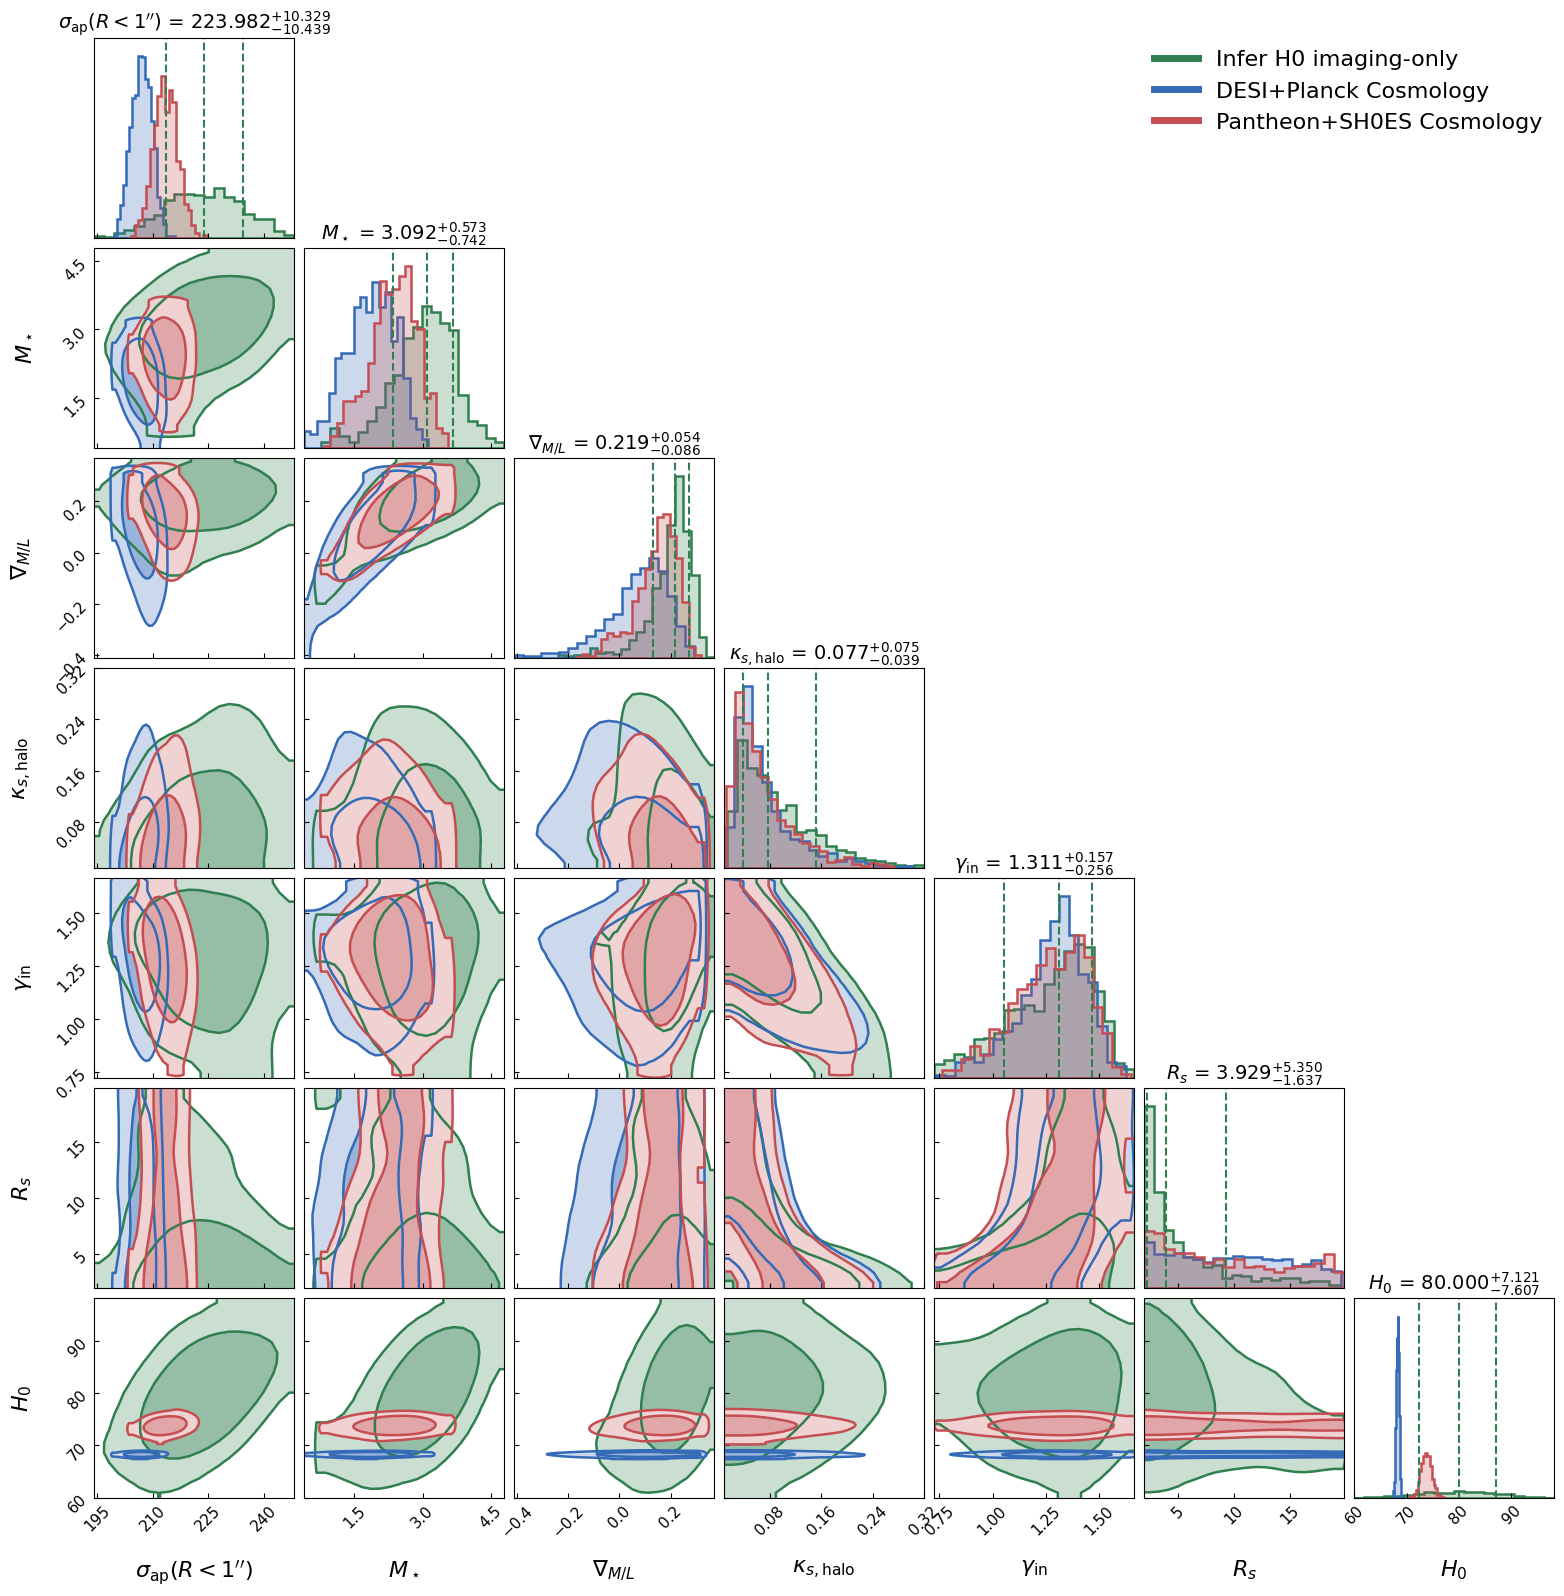

In [13]:
# ============================================================
# Overlay corner plot
# ============================================================
corner_vars = [
    'sigma_ap_1p0_arcsec_km_s',
    # 'beta_cyl',
    'm2l_ratio',
    'm2l_ratio_slope',
    'kappa_s_halo',
    'gammain_halo',
    'Rs_halo',
    'H0_cosmo_blinded',
]
labels = [
    r'$\sigma_{\rm ap}(R<1^{\prime\prime})$',
    # r'$\beta_{\rm cyl}$',
    r'$M_\star$',
    r'$\nabla_{M/L}$',
    r'$\kappa_{s,\rm halo}$',
    r'$\gamma_{\rm in}$',
    r'$R_s$',
    r'$H_0$',
]

plot_results = {}
for run_name, df in jam_results.items():
    df_plot = df.copy()
    if run_name == 'infer_h0_imaging_only':
        h0_blind_offset = 80.0 - np.nanmedian(df_plot['H0_cosmo'])
    else:
        h0_blind_offset = 0.0
    df_plot['H0_cosmo_blinded'] = df_plot['H0_cosmo'] + h0_blind_offset
    plot_results[run_name] = df_plot
    print(f'{RUN_CONFIGS[run_name]["label"]}: H0 blind offset = {h0_blind_offset:.4f}; plotted H0 median = {np.nanmedian(df_plot["H0_cosmo_blinded"]):.4f}')

fig = None
for run_name, cfg in RUN_CONFIGS.items():
    color = cfg['color']
    fig = corner.corner(
        plot_results[run_name][corner_vars],
        fig=fig,
        labels=labels,
        color=color,
        quantiles=[0.16, 0.5, 0.84] if fig is None else None,
        show_titles=(fig is None),
        title_fmt='.3f',
        smooth=2,
        levels=[0.68, 0.95],
        plot_datapoints=False,
        plot_density=False,
        fill_contours=True,
        hist_kwargs={'density': True, 'histtype': 'stepfilled', 'linewidth': 1.8, 'edgecolor': color, 'facecolor': to_rgba(color, 0.25)},
        contour_kwargs={'linewidths': 1.8, 'colors': color},
        contourf_kwargs={'colors': [to_rgba(color, 0.00), to_rgba(color, 0.25), to_rgba(color, 0.50)], 'antialiased': True},
        label_kwargs={'fontsize': 16},
        title_kwargs={'fontsize': 14},
        max_n_ticks=4,
    )

fig.legend(
    handles=[plt.Line2D([], [], color=cfg['color'], lw=5, label=cfg['label']) for cfg in RUN_CONFIGS.values()],
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98),
    frameon=False,
    fontsize=16,
)

for ax in fig.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=11, direction='in')
    ax.tick_params(axis='both', which='minor', direction='in')

fig.savefig(CORNER_OUT, dpi=300, bbox_inches='tight')
print('saved corner plot to', CORNER_OUT)
plt.show()
